# Music Sheet Symbol Detector

OMR pipeline on DeepScoresV2: preprocessing, staff removal, notehead segmentation and evaluation.

In [16]:
import os, json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import Counter
from classifier import SymbolClassifier, build_training_data, extract_features, level1_label, level2_label
from otsu import OtsuThreshold

from classifier import NOTEHEAD_BLACK, NOTEHEAD_HALF, NOTEHEAD_WHOLE

## 1. Dataset

DeepScoresV2 dense split - 1362 images, 135 classes, annotations in COCO-like JSON format.

In [17]:
# run once to download
# import requests, tarfile
# from tqdm import tqdm
#
# def download_file(url, dest):
#     os.makedirs(os.path.dirname(dest), exist_ok=True)
#     r = requests.get(url, stream=True)
#     total = int(r.headers.get('content-length', 0))
#     with open(dest, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True, desc=dest) as bar:
#         for chunk in r.iter_content(8192):
#             f.write(chunk)
#             bar.update(len(chunk))
#
# download_file("https://zenodo.org/records/4012193/files/ds2_dense.tar.gz", "data/ds2_dense.tar.gz")
# with tarfile.open("data/ds2_dense.tar.gz", "r:gz") as tar:
#     tar.extractall("data/", filter='data')

In [18]:
with open("data/ds2_dense/deepscores_train.json") as f:
    data = json.load(f)

categories = {k: v for k, v in data['categories'].items() if v['annotation_set'] == 'deepscores'}
id_to_name = {k: v['name'] for k, v in categories.items()}

anns_by_img = {}
for ann_id, ann in data['annotations'].items():
    anns_by_img.setdefault(ann['img_id'], []).append(ann)

print(f"{len(categories)} classes, {len(anns_by_img)} images")

136 classes, 1362 images


## 2. Load & binarisation

In [19]:
sample_img_info = next(i for i in data['images'] if i['filename'] == 'lg-214320686-aug-lilyjazz--page-3.png')
img = cv2.imread(f"data/ds2_dense/images/{sample_img_info['filename']}")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_id = str(sample_img_info['id'])
sample_anns = anns_by_img.get(img_id, [])

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, img_bin = OtsuThreshold.apply(img_gray)
h_img, w_img = img_bin.shape
print(f"Image : {w_img}x{h_img}")

Image : 1960x2772


## 3. Ground truth noteheads

In [20]:
notehead_cats = {
    'noteheadBlackOnLine', 'noteheadBlackInSpace',
    'noteheadWholeOnLine', 'noteheadWholeInSpace',
    'noteheadHalfOnLine', 'noteheadHalfInSpace',
}

gt_noteheads = []
for ann in sample_anns:
    if id_to_name.get(ann['cat_id'][0], '?') in notehead_cats:
        x1, y1, x2, y2 = ann['a_bbox']
        gt_noteheads.append((int(x1), int(y1), int(x2), int(y2)))

avg_w = np.mean([x2 - x1 for (x1, y1, x2, y2) in gt_noteheads])
avg_h = np.mean([y2 - y1 for (x1, y1, x2, y2) in gt_noteheads])
print(f"GT noteheads : {len(gt_noteheads)}, taille moyenne : {avg_w:.1f} x {avg_h:.1f} px")

GT noteheads : 183, taille moyenne : 22.3 x 17.3 px


## 4. Preprocessing

- Suppression des lignes de portée
- Fermeture pour reboucher les trous
- Suppression des barres de mesure et des hampes.

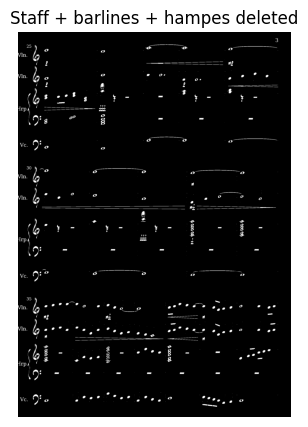

In [21]:
# staff lines: long horizontal structures
kernel_horiz = cv2.getStructuringElement(cv2.MORPH_RECT, (w_img // 4, 1))
staff = cv2.dilate(cv2.erode(img_bin, kernel_horiz), kernel_horiz)
img_no_staff = cv2.subtract(img_bin, staff)

# vertical closing : fill holes in noteheads on-line
kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 3))
img_no_staff = cv2.morphologyEx(img_no_staff, cv2.MORPH_CLOSE, kernel_close)

# barlines : tall vertical structures
kernel_vert = cv2.getStructuringElement(cv2.MORPH_RECT, (1, h_img // 20))
bars = cv2.dilate(cv2.erode(img_no_staff, kernel_vert), kernel_vert)
img_no_staff_no_bars = cv2.subtract(img_no_staff, bars)

# Hampes : short vertical structures (> 2x height head)
kernel_stem = cv2.getStructuringElement(cv2.MORPH_RECT, (1, int(avg_h * 2)))
stems = cv2.dilate(cv2.erode(img_no_staff_no_bars, kernel_stem), kernel_stem)
img_clean = cv2.subtract(img_no_staff_no_bars, stems)

plt.figure(figsize=(14, 5))
plt.imshow(img_clean, cmap='gray')
plt.title("Staff + barlines + hampes deleted")
plt.axis('off')
plt.show()

## 5. Segmentation

Connected components on the cleaned image. We filter by size and aspect ratio to keep notehead-shaped blobs.

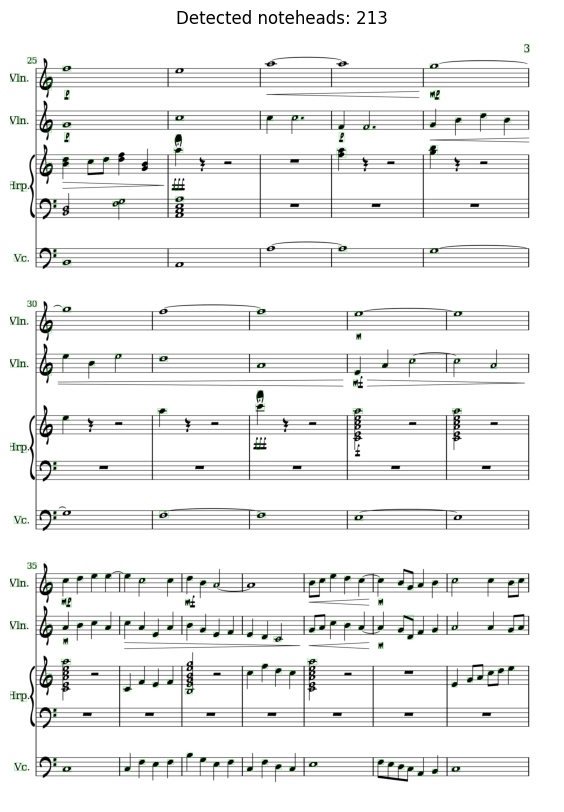

In [22]:
num_labels, _, stats, _ = cv2.connectedComponentsWithStats(img_clean)

detected_noteheads = []
for i in range(1, num_labels):
    x, y, w, h, area = stats[i]
    aspect = w / h if h > 0 else 0
    if 0.5 < aspect < 2.0 and avg_w * 0.4 < w < avg_w * 2 and h < avg_h * 2 and area > 15:
        detected_noteheads.append((x, y, x + w, y + h))

img_seg = img_rgb.copy()
for (x1, y1, x2, y2) in detected_noteheads:
    cv2.rectangle(img_seg, (x1, y1), (x2, y2), (0, 200, 0), 1)
plt.figure(figsize=(14, 10))
plt.imshow(img_seg)
plt.title(f"Detected noteheads: {len(detected_noteheads)}")
plt.axis('off')
plt.show()

## 6. Detection Evaluation

GT: 183  Detected: 213
TP=138  FP=75  FN=45
Precision: 0.648  Recall: 0.754  F1: 0.697


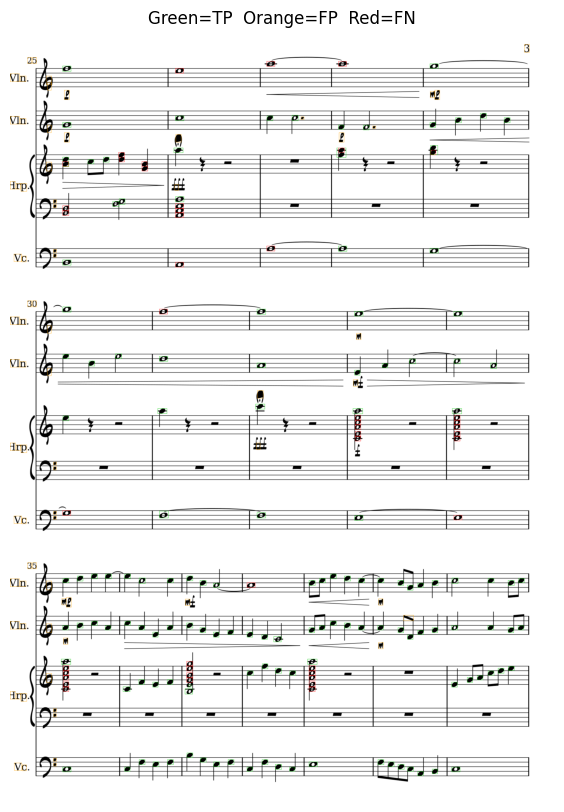

In [23]:
def center_in_box(det, gt):
    cx = (det[0] + det[2]) / 2
    cy = (det[1] + det[3]) / 2
    return gt[0] <= cx <= gt[2] and gt[1] <= cy <= gt[3]


def evaluate(detections, gt_boxes):
    tp, fp, matched = 0, 0, set()
    for det in detections:
        hit = False
        for i, gt in enumerate(gt_boxes):
            if i not in matched and center_in_box(det, gt):
                tp += 1;
                matched.add(i);
                hit = True;
                break
        if not hit:
            fp += 1
    fn = len(gt_boxes) - len(matched)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return tp, fp, fn, precision, recall, f1, matched


tp, fp, fn, precision, recall, f1, matched = evaluate(detected_noteheads, gt_noteheads)
print(f"GT: {len(gt_noteheads)}  Detected: {len(detected_noteheads)}")
print(f"TP={tp}  FP={fp}  FN={fn}")
print(f"Precision: {precision:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}")

img_eval = img_rgb.copy()
tp_dets = [d for d in detected_noteheads if any(center_in_box(d, gt_noteheads[i]) for i in matched)]
fp_dets = [d for d in detected_noteheads if d not in tp_dets]
fn_boxes = [gt for i, gt in enumerate(gt_noteheads) if i not in matched]
for (x1, y1, x2, y2) in tp_dets:  cv2.rectangle(img_eval, (x1, y1), (x2, y2), (0, 200, 0), 1)
for (x1, y1, x2, y2) in fp_dets:  cv2.rectangle(img_eval, (x1, y1), (x2, y2), (255, 165, 0), 1)
for (x1, y1, x2, y2) in fn_boxes: cv2.rectangle(img_eval, (x1, y1), (x2, y2), (255, 0, 0), 1)
plt.figure(figsize=(14, 10))
plt.imshow(img_eval)
plt.title("Green=TP  Orange=FP  Red=FN")
plt.axis('off')
plt.show()

## 7. Detections vs Ground Truth

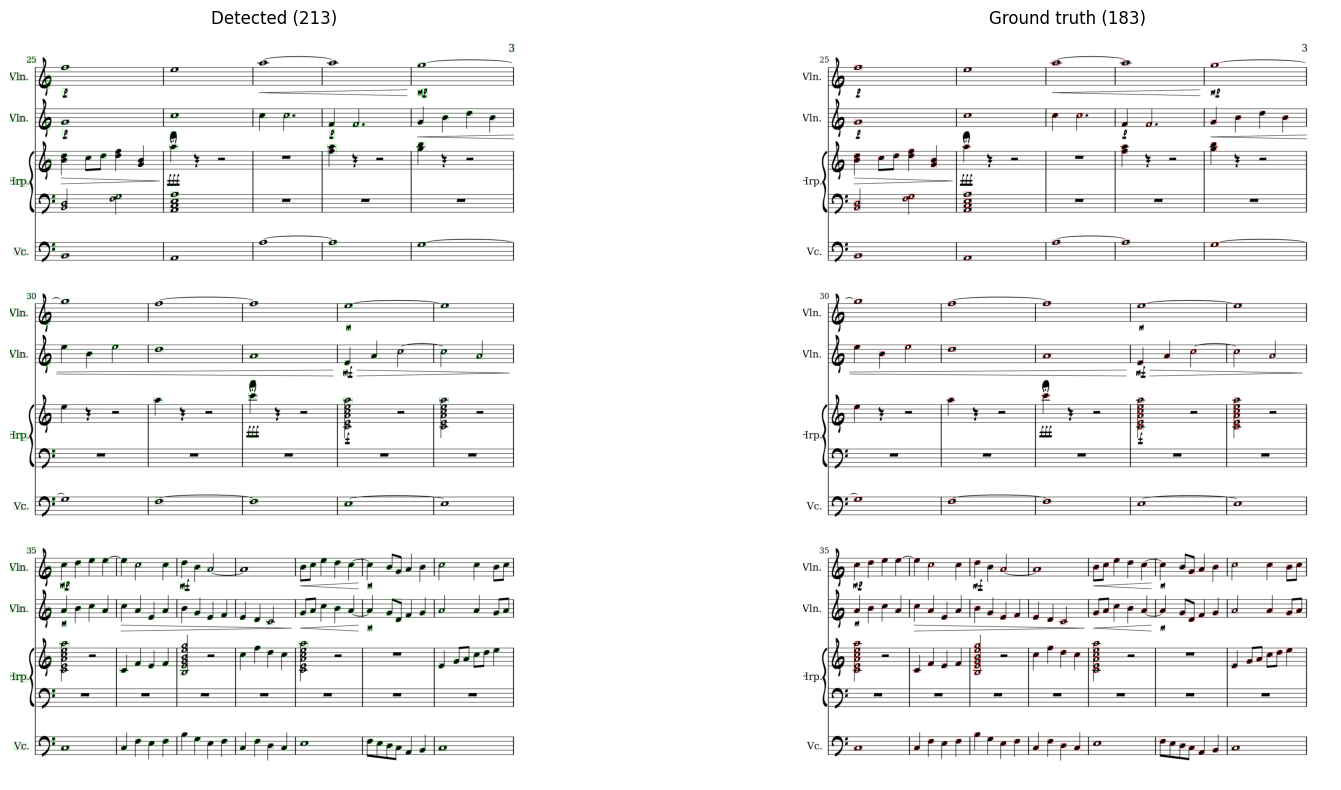

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

img_det = img_rgb.copy()
for (x1, y1, x2, y2) in detected_noteheads:
    cv2.rectangle(img_det, (x1, y1), (x2, y2), (0, 200, 0), 1)

img_gt = img_rgb.copy()
for (x1, y1, x2, y2) in gt_noteheads:
    cv2.rectangle(img_gt, (x1, y1), (x2, y2), (255, 0, 0), 1)

ax1.imshow(img_det); ax1.set_title(f"Detected ({len(detected_noteheads)})"); ax1.axis('off')
ax2.imshow(img_gt);  ax2.set_title(f"Ground truth ({len(gt_noteheads)})");  ax2.axis('off')
plt.tight_layout()
plt.show()

## 8. Classification

Two-level kNN: first classify each blob as notehead / rest / clef / other,
then among noteheads distinguish black / half / whole.
Features: Hu moments (7) + pixel density + aspect ratio.

In [25]:
# train on several images, test on sample_img_info
TRAIN_FILENAMES = [
    'lg-233786100286899765-aug-gutenberg1939--page-2.png',
    'lg-797958438447858728-aug-lilyjazz--page-1.png',
    'lg-827327016295735829-aug-beethoven--page-1.png',
    'lg-138696691-aug-gutenberg1939--page-1.png',
    'lg-523155381240242384-aug-lilyjazz--page-41.png',
    'lg-214320686-aug-lilyjazz--page-3.png',
    'lg-43865734-aug-beethoven--page-2.png',
    'lg-359041762321484926-aug-emmentaler-.png',
]

X_all, y_l1_all, y_l2_all = [], [], []
for fname in TRAIN_FILENAMES:
    info = next((i for i in data['images'] if i['filename'] == fname), None)
    if info is None:
        continue
    anns = anns_by_img.get(str(info['id']), [])
    img_tr = cv2.imread(f"data/ds2_dense/images/{fname}")
    img_gray_tr = cv2.cvtColor(img_tr, cv2.COLOR_BGR2GRAY)
    _, img_bin_tr = OtsuThreshold.apply(img_gray_tr)
    X_tr, y_l1_tr, y_l2_tr = build_training_data(anns, id_to_name, img_bin_tr)
    X_all.append(X_tr)
    y_l1_all += y_l1_tr
    y_l2_all += y_l2_tr

X_all = np.concatenate(X_all)
clf = SymbolClassifier(k=5)
clf.fit(X_all, y_l1_all, y_l2_all)
print(f"Training samples: {len(X_all)} from {len(TRAIN_FILENAMES)} images")

Training samples: 2842 from 8 images


In [26]:
X_test = []
for (x1, y1, x2, y2) in detected_noteheads:
    blob = img_bin[y1:y2, x1:x2]
    X_test.append(extract_features(blob))
X_test = np.array(X_test)

preds = clf.predict(X_test)
print(f"Classified {len(preds)} blobs")

Classified 213 blobs


In [27]:
gt_l1, gt_l2 = [], []
pred_l1, pred_l2 = [], []

for i, (x1, y1, x2, y2) in enumerate(detected_noteheads):
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    for ann in sample_anns:
        ax1, ay1, ax2, ay2 = ann['a_bbox']
        ann_cx, ann_cy = (ax1 + ax2) / 2, (ay1 + ay2) / 2
        if abs(cx - ann_cx) < avg_w and abs(cy - ann_cy) < avg_h:
            cat = id_to_name.get(ann['cat_id'][0], '?')
            gt_l1.append(level1_label(cat))
            gt_l2.append(level2_label(cat))
            pred_l1.append(preds[i][0])
            pred_l2.append(preds[i][1])
            break

# only evaluate where both GT and pred have a valid level 2 label
nh_idx = [i for i, (g, p) in enumerate(zip(gt_l2, pred_l2))
          if g is not None and p is not None]
gt_l2_nh   = [gt_l2[i]   for i in nh_idx]
pred_l2_nh = [pred_l2[i] for i in nh_idx]

print(f"Level 2 accuracy (black/half/whole): {accuracy_score(gt_l2_nh, pred_l2_nh):.3f}")
print(confusion_matrix(gt_l2_nh, pred_l2_nh))

Level 2 accuracy (black/half/whole): 0.983
[[88  0  0]
 [ 0 12  0]
 [ 0  2 18]]


Counter({'black': 106, None: 57, 'half': 27, 'whole': 23})


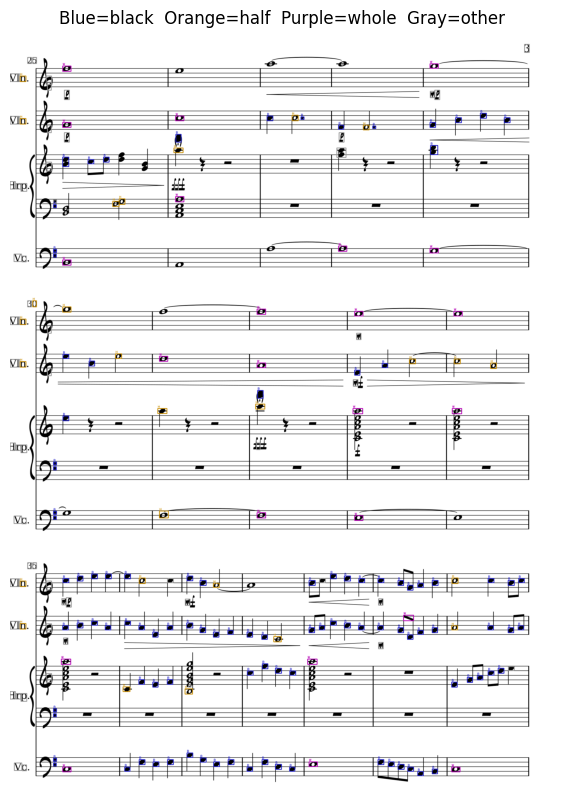

In [28]:
colors = {'black': (30, 30, 200), 'half': (200, 140, 0), 'whole': (180, 0, 180)}

img_classif = img_rgb.copy()
for i, (x1, y1, x2, y2) in enumerate(detected_noteheads):
    l2 = preds[i][1]
    color = colors.get(l2, (150, 150, 150))  # gray for unclassified
    cv2.rectangle(img_classif, (x1, y1), (x2, y2), color, 2)
    if l2:
        cv2.putText(img_classif, l2[0].upper(), (x1, y1 - 3),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, color, 1, cv2.LINE_AA)

print(Counter(preds[i][1] for i in range(len(preds))))
plt.figure(figsize=(14, 10))
plt.imshow(img_classif)
plt.title("Blue=black  Orange=half  Purple=whole  Gray=other")
plt.axis('off')
plt.show()

## 9. mAP Evaluation (IoU-based)

In [29]:
def compute_iou(b1, b2):
    xi1, yi1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    xi2, yi2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    union = (b1[2]-b1[0])*(b1[3]-b1[1]) + (b2[2]-b2[0])*(b2[3]-b2[1]) - inter
    return inter / union if union > 0 else 0

def ap_at_05(dets, gts):
    matched, tp, fp = set(), 0, 0
    for det in dets:
        best = max(range(len(gts)), key=lambda i: compute_iou(det, gts[i]), default=-1)
        if best >= 0 and compute_iou(det, gts[best]) >= 0.5 and best not in matched:
            tp += 1; matched.add(best)
        else:
            fp += 1
    fn = len(gts) - len(matched)
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    return 2 * p * r / (p + r) if (p + r) > 0 else 0

In [30]:
classes = {'black': NOTEHEAD_BLACK, 'half': NOTEHEAD_HALF, 'whole': NOTEHEAD_WHOLE}

gt_per_class  = {c: [] for c in classes}
det_per_class = {c: [] for c in classes}

for ann in sample_anns:
    cat = id_to_name.get(ann['cat_id'][0], '?')
    box = tuple(int(v) for v in ann['a_bbox'])
    for c, cats in classes.items():
        if cat in cats:
            gt_per_class[c].append(box)

for i, box in enumerate(detected_noteheads):
    l2 = preds[i][1]
    if l2 in det_per_class:
        det_per_class[l2].append(box)

aps = {c: ap_at_05(det_per_class[c], gt_per_class[c]) for c in classes}
for c, ap in aps.items():
    print(f"F1@IoU0.5  {c:8s}: {ap:.3f}")
print(f"\nmAP: {np.mean(list(aps.values())):.3f}")

F1@IoU0.5  black   : 0.840
F1@IoU0.5  half    : 0.389
F1@IoU0.5  whole   : 0.655

mAP: 0.628


## 10. Staff line detection

Staff lines : 75


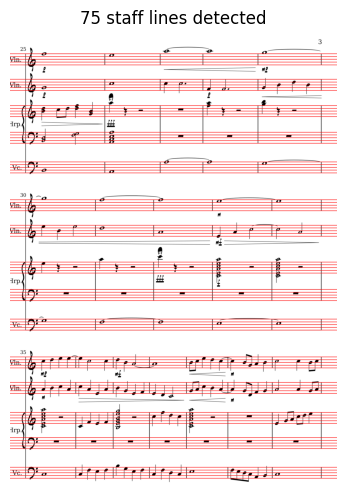

In [31]:
# short kernal width to avoid interruptions
kernel_staff = cv2.getStructuringElement(cv2.MORPH_RECT, (w_img // 8, 1))
staff_mask = cv2.dilate(cv2.erode(img_bin, kernel_staff), kernel_staff)

# nbr px on y line
h_proj = staff_mask.sum(axis=1).astype(float)
# staff line > 30% width
threshold_px = 0.30 * w_img * 255
staff_ys = np.where(h_proj > threshold_px)[0]

# merge staff line on the same run
staff_line_ys = []
if len(staff_ys) > 0:
    run_start = prev = staff_ys[0]
    for y in staff_ys[1:]:
        # detect gap between two staff lines
        if y - prev > 3:
            staff_line_ys.append((run_start + prev) // 2)
            run_start = y
        prev = y
    staff_line_ys.append((run_start + prev) // 2)

print(f"Staff lines : {len(staff_line_ys)}")

vis_staff = img_rgb.copy()
for y in staff_line_ys:
    cv2.line(vis_staff, (0, y), (w_img, y), 255, 2)

plt.figure(figsize=(14, 6))
plt.imshow(vis_staff)
plt.title(f"{len(staff_line_ys)} staff lines detected")
plt.axis('off')
plt.show()

## 11. Group by staff

In [32]:
diffs = np.diff(staff_line_ys)
staff_spacing = int(np.median(diffs))
print(f"Staff spacing : {staff_spacing} px")

staves, current = [], [staff_line_ys[0]]
for i in range(1, len(staff_line_ys)):
    # gap between 2 staffs > 2x spacing
    if staff_line_ys[i] - staff_line_ys[i - 1] > 2 * staff_spacing:
        staves.append(current)
        current = []
    current.append(staff_line_ys[i])
staves.append(current)

print(f"{len(staves)} staffs :")
for i, s in enumerate(staves):
    print(f"  Staff {i} : {len(s)} lines")

Staff spacing : 17 px
15 staffs :
  Staff 0 : 5 lines
  Staff 1 : 5 lines
  Staff 2 : 5 lines
  Staff 3 : 5 lines
  Staff 4 : 5 lines
  Staff 5 : 5 lines
  Staff 6 : 5 lines
  Staff 7 : 5 lines
  Staff 8 : 5 lines
  Staff 9 : 5 lines
  Staff 10 : 5 lines
  Staff 11 : 5 lines
  Staff 12 : 5 lines
  Staff 13 : 5 lines
  Staff 14 : 5 lines


## 12. Pitch Accuracy

Suppose Sol key

GT with pitch : 183


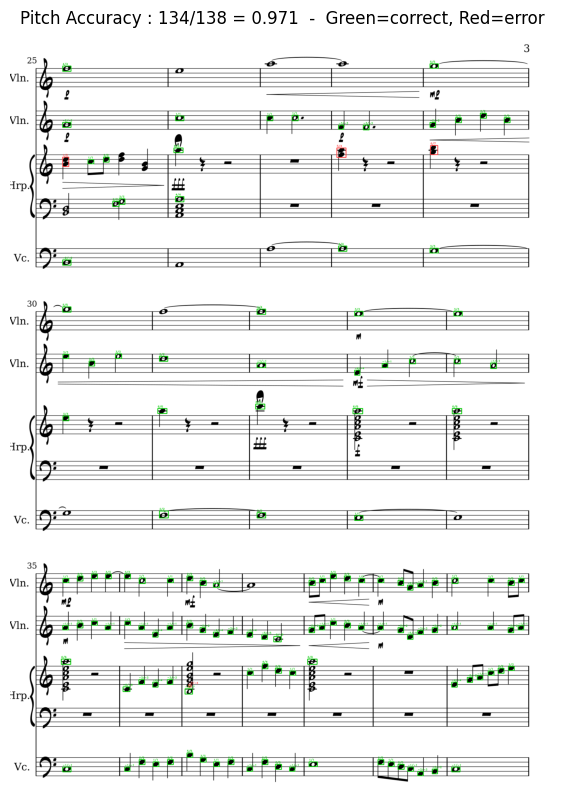

In [33]:
def parse_rel_position(ann) -> int|None:
    """
    example: 'instance:#000042;duration:8;rel_position:-4;
    :return: rel_position
    """
    for part in ann.get('comments', '').split(';'):
        if part.startswith('rel_position:'):
            return int(part.split(':')[1])
    return None


# list[(bbox, rel_position)]
gt_pitches = []
for ann in sample_anns:
    if id_to_name.get(ann['cat_id'][0], '?') in notehead_cats:
        x1, y1, x2, y2 = ann['a_bbox']
        rel = parse_rel_position(ann)
        if rel is not None:
            gt_pitches.append((int(x1), int(y1), int(x2), int(y2), rel))
print(f"GT with pitch : {len(gt_pitches)}")


def get_cy_from_pixels(bbox, img_bin):
    """Y center mass in bbox"""
    x1, y1, x2, y2 = bbox
    ys, _ = np.where(img_bin[y1:y2, x1:x2] > 0)
    return y1 + np.mean(ys) if len(ys) > 0 else (y1 + y2) / 2.0


def rel_position_from_y(note_cy, staff_lines_ys):
    sorted_ys = sorted(staff_lines_ys)
    line_rels = [4, 2, 0, -2, -4]
    top_sp = sorted_ys[1] - sorted_ys[0]
    bot_sp = sorted_ys[-1] - sorted_ys[-2]

    all_positions = {}
    # Lines
    for rel, y in zip(line_rels, sorted_ys):
        all_positions[rel] = float(y)

    # Spaces : exact middle between two adjacent lines
    for i in range(len(sorted_ys) - 1):
        all_positions[line_rels[i] - 1] = (sorted_ys[i] + sorted_ys[i + 1]) / 2.0

    # Ledger lines (3 levels above or below)
    for d in [1, 2, 3]:
        all_positions[4 + d * 2] = sorted_ys[0] - d * top_sp
        all_positions[-4 - d * 2] = sorted_ys[-1] + d * bot_sp
        all_positions[4 + d * 2 - 1] = sorted_ys[0] - (d - 0.5) * top_sp
        all_positions[-4 - d * 2 + 1] = sorted_ys[-1] + (d - 0.5) * bot_sp

    return min(all_positions, key=lambda r: abs(all_positions[r] - note_cy))


correct, total = 0, 0
vis_pitch_acc = img_rgb.copy()

for (x1, y1, x2, y2) in detected_noteheads:
    cx = (x1 + x2) / 2
    cy = get_cy_from_pixels((x1, y1, x2, y2), img_bin)

    best_staff = min(staves, key=lambda s: min(abs(cy - y) for y in s))
    pred_rel = rel_position_from_y(cy, best_staff)

    gt_rel = None
    for (gx1, gy1, gx2, gy2, rel) in gt_pitches:
        if gx1 <= cx <= gx2 and gy1 <= cy <= gy2:
            gt_rel = rel
            break

    if gt_rel is not None:
        total += 1
        ok = pred_rel == gt_rel
        correct += ok
        color = (0, 200, 0) if ok else (255, 60, 60)
        cv2.rectangle(vis_pitch_acc, (x1, y1), (x2, y2), color, 2)
        cv2.putText(vis_pitch_acc, f"{pred_rel}/{gt_rel}", (x1, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.3, color, 1, cv2.LINE_AA)

plt.figure(figsize=(16, 10))
plt.imshow(vis_pitch_acc)
plt.title(f"Pitch Accuracy : {correct}/{total} = {correct / total:.3f}  -  Green=correct, Red=error")
plt.axis('off')
plt.show()